In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.pipeline import Pipeline

In [4]:
X = 6*np.random.rand(200,1)-3

In [5]:
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

In [8]:
X.shape

(200, 1)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = lr.predict(X_test)

In [13]:
r2_score(y_test,y_pred)

0.3846456898047418

In [14]:
sgd = SGDRegressor(learning_rate='constant', eta0=0.05)

In [16]:
sgd.fit(X_train,y_train.ravel())

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [17]:
y_pred = sgd.predict(X_test)

In [18]:
r2_score(y_test,y_pred)

0.49462556991813056

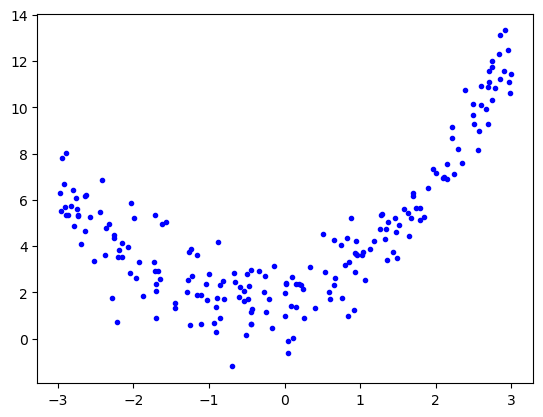

In [29]:
plt.plot(X,y,'b.')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

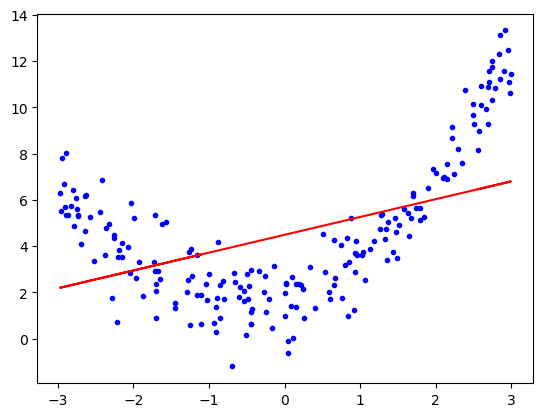

In [35]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),c='r')
plt.show

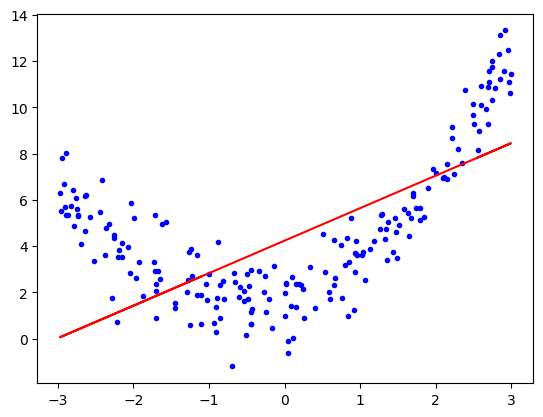

In [37]:
plt.plot(X,y,'b.')
plt.plot(X,sgd.predict(X),c='r')
plt.show()

In [104]:
poly = PolynomialFeatures(degree=2)

In [105]:
X_train_trans = poly.fit_transform(X_train)

In [106]:
X_test_trans = poly.transform(X_test)

In [111]:
scaler = StandardScaler()

In [113]:
ss_X_train = scaler.fit_transform(X_train_trans)

In [114]:
ss_X_test = scaler.transform(X_test_trans)

In [115]:
lr = LinearRegression()

In [116]:
lr.fit(ss_X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [117]:
y_pred = lr.predict(ss_X_test)

In [118]:
r2_score(y_test,y_pred)

0.9078958365297174

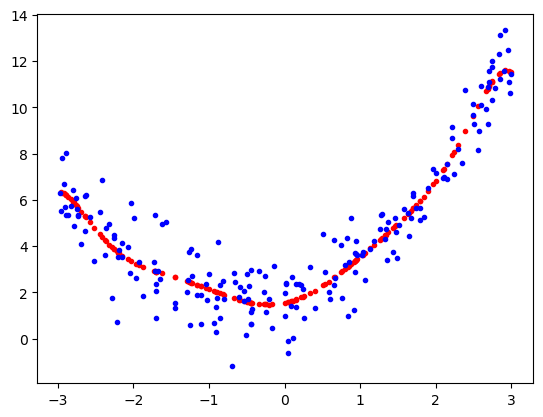

In [103]:
plt.plot(X_train,lr.predict(X_train_trans),'r.')
plt.plot(X,y,'b.')
plt.show()